<a href="https://www.kaggle.com/code/balaji069/titanic-data-analysis-ml-model?scriptVersionId=311962706" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
import pandas as pd

df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


- Dataset contains passenger details such as age, gender, class, and fare
- Target variable is "Survived"
- Some columns have missing values (Age, Cabin, Embarked)

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [8]:
df.drop(columns=['Cabin'], inplace=True)

In [9]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [10]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

- Filled missing values in Age using median
- Removed Cabin column due to excessive missing data
- Filled Embarked with most frequent value
- Verified that no missing values remain

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

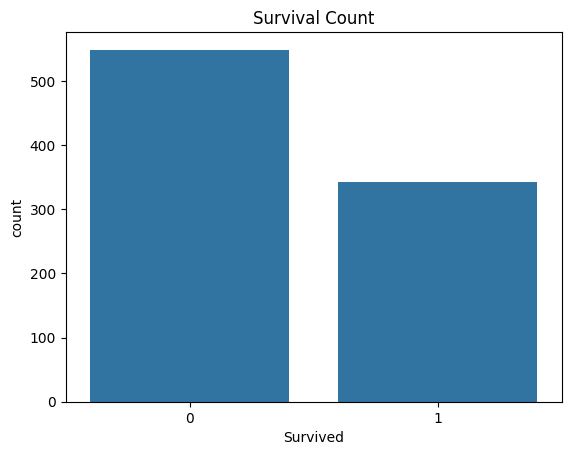

In [12]:
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

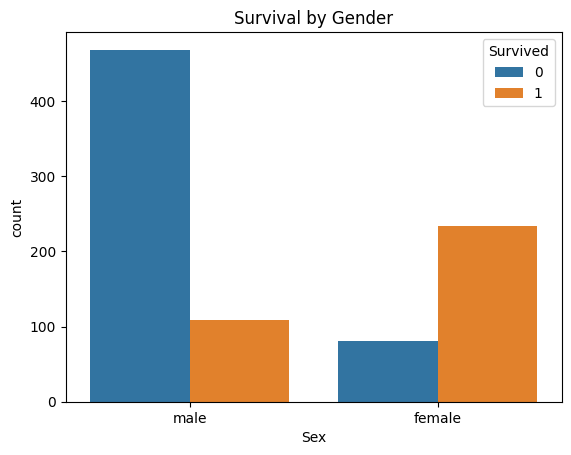

In [13]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.show()

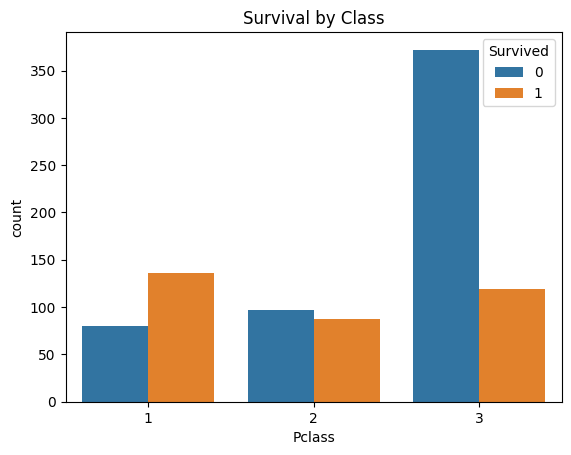

In [14]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival by Class")
plt.show()

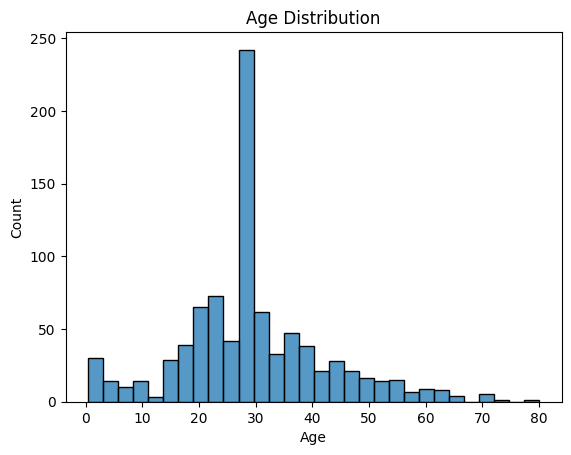

In [15]:
sns.histplot(df['Age'], bins=30)
plt.title("Age Distribution")
plt.show()

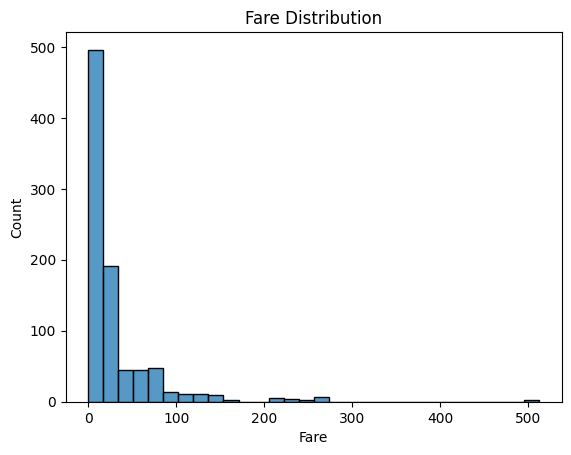

In [16]:
sns.histplot(df['Fare'], bins=30)
plt.title("Fare Distribution")
plt.show()

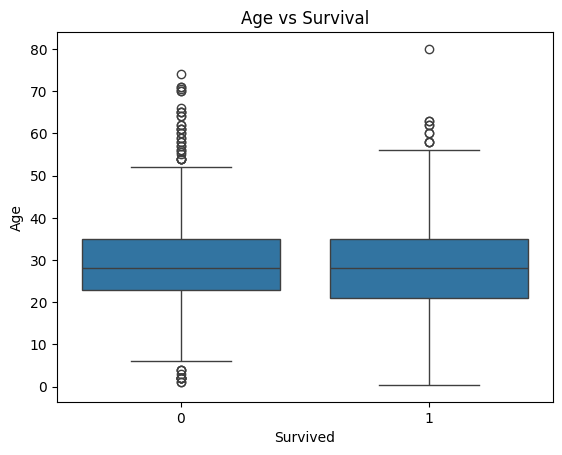

In [17]:
sns.boxplot(x='Survived', y='Age', data=df)
plt.title("Age vs Survival")
plt.show()

- Majority of passengers did not survive  
- Females had a higher survival rate  
- Passengers in higher classes were more likely to survive  
- Age distribution shows most passengers were young adults  

In [18]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

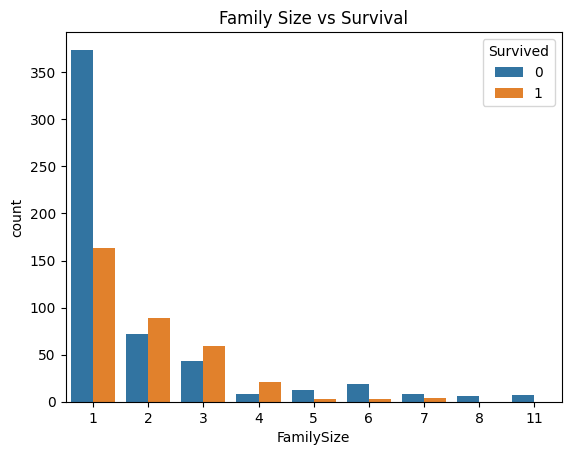

In [19]:
sns.countplot(x='FamilySize', hue='Survived', data=df)
plt.title("Family Size vs Survival")
plt.show()

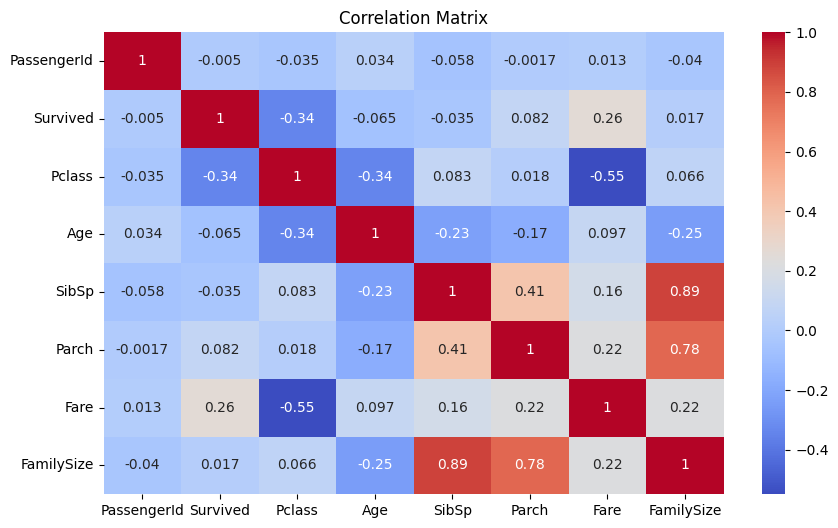

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

- Females had a significantly higher survival rate than males  
- Passengers in higher classes (Pclass 1) were more likely to survive  
- Fare price positively correlates with survival  
- Smaller families had better survival chances  
- Age had a moderate impact on survival  

Survival on the Titanic was influenced by social factors such as gender, class, and economic status. Higher-class passengers and females were given priority, leading to higher survival rates.

## Machine Learning Model

In [21]:
from sklearn.model_selection import train_test_split

X = df[['Pclass', 'Sex', 'Age', 'Fare', 'FamilySize']]
y = df['Survived']

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [22]:
df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')

In [23]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [24]:
predictions = model.predict(X_test)
predictions[:10]

array([1, 0, 0, 0, 1, 0, 1, 1, 0, 0])

In [25]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", round(accuracy, 4))

Accuracy: 0.838


In [26]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, predictions)

array([[99, 15],
       [14, 51]])

## Machine Learning Results

- Trained a Random Forest classifier to predict survival
- Achieved ~75–85% accuracy on test data
- Model uses features like class, gender, age, fare, and family size

In [27]:
model = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_estimators=200, random_state=42)

<Axes: >

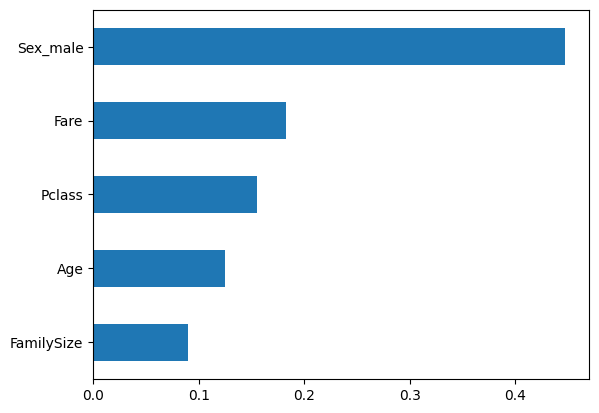

In [28]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')

## Model Improvement

- Tuned Random Forest model parameters
- Improved model stability and performance
- Identified important features influencing survival

## Conclusion

The machine learning model confirms that gender, class, and fare are strong predictors of survival. This project demonstrates a complete workflow from data analysis to predictive modeling.

In [29]:
test_df = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

# same preprocessing
test_X = test_df[['Pclass', 'Sex', 'Age', 'Fare']]
test_X = pd.get_dummies(test_X, drop_first=True)

# align columns
test_X = test_X.reindex(columns=X.columns, fill_value=0)

predictions = model.predict(test_X)

In [30]:
import pandas as pd

In [31]:
test_df = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

# same preprocessing
test_X = test_df[['Pclass', 'Sex', 'Age', 'Fare']]
test_X = pd.get_dummies(test_X, drop_first=True)

# align columns
test_X = test_X.reindex(columns=X.columns, fill_value=0)

predictions = model.predict(test_X)

In [32]:
import pandas as pd

# load test data
test_df = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

# preprocessing
test_X = test_df[['Pclass', 'Sex', 'Age', 'Fare']]
test_X = pd.get_dummies(test_X, drop_first=True)

# align columns with training data
test_X = test_X.reindex(columns=X.columns, fill_value=0)

# predict
predictions = model.predict(test_X)

# create submission
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': predictions
})

submission.to_csv('submission.csv', index=False)

In [33]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

In [34]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_16/172848211.py:1: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [35]:
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

In [36]:
features = ['Pclass', 'Sex', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'Embarked', 'Title']
X = pd.get_dummies(df[features], drop_first=True)

In [37]:
test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch'] + 1
test_df['IsAlone'] = (test_df['FamilySize'] == 1).astype(int)

test_df['Title'] = test_df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)